# Regime Yield-Curve Classifier

Assigns one of six yield-curve regimes to each trading day using nominal 2Y and 10Y Treasury yields. Output: `data/interest_rate_regimes.xlsx`.

## Specification

**Inputs.** Daily 2Y and 10Y Treasury yields $y^{(2)}_t, y^{(10)}_t$ (FRED tickers `DGS2`, `DGS10`). Spread:

$$ S_t = y^{(10)}_t - y^{(2)}_t. $$

### 1. Trend differentials

For each series, subtract the 200-day SMA from the 21-day SMA:

$$ d^{(i)}_t = \text{SMA}_{21}\!\left(y^{(i)}_t\right) - \text{SMA}_{200}\!\left(y^{(i)}_t\right), \qquad i \in \{2, 10\}. $$

The spread trend follows by linearity:

$$ d^{(S)}_t = d^{(10)}_t - d^{(2)}_t = \text{SMA}_{21}(S_t) - \text{SMA}_{200}(S_t). $$

First 200 days have no labels.

### 2. Direction flags

Sign each differential, with a basis-point dead-zone $\tau$ to suppress noise:

$$ u^{(i)}_t = \begin{cases} +1 & d^{(i)}_t > \tau^{(i)} \\ -1 & d^{(i)}_t < -\tau^{(i)} \\ \phantom{+}0 & \lvert d^{(i)}_t \rvert \le \tau^{(i)} \end{cases} $$

Defaults: $\tau^{(2)} = \tau^{(10)} = 10$ bp on yields, $\tau^{(S)} = 5$ bp on the spread.

### 3. Decision table

| $u^{(2)}$ | $u^{(10)}$ | $u^{(S)}$ | Regime |
|:-:|:-:|:-:|---|
| $-1$ | $-1$ | $+1$ | **Bull Steepener** |
| $-1$ | $-1$ | $-1$ | **Bull Flattener** |
| $+1$ | $+1$ | $+1$ | **Bear Steepener** |
| $+1$ | $+1$ | $-1$ | **Bear Flattener** |
| $-1$ | $+1$ | $+1$ (forced) | **Steepener Twist** |
| $+1$ | $-1$ | $-1$ (forced) | **Flattener Twist** |
| any $0$ | — | — | **Unclassified** |

In twist rows $u^{(S)}$ is mechanically pinned by $u^{(2)}, u^{(10)}$.

### 4. Persistence filter

Commit a new label only after $k = 5$ consecutive trading days of the same raw label; otherwise carry the prior committed label forward.

### References

- Lutey, M., & Rayome, D. — 21/200 SMA trend convention.
- Sullivan, R., Timmermann, A., & White, H. (1999). *Data-Snooping, Technical Trading Rule Performance, and the Bootstrap*. Journal of Finance 54(5), 1647–1691 — magnitude-threshold and persistence design.

In [1]:
from __future__ import annotations

import io
import ssl
import urllib.request
from pathlib import Path

import numpy as np
import pandas as pd

REPO = Path.cwd() if (Path.cwd() / "data").exists() else Path.cwd().parent
DATA = REPO / "data"
OUT_XLSX = DATA / "interest_rate_regimes.xlsx"
YIELD_CACHE = DATA / "treasury_yields_2y_10y.csv"

SMA_FAST, SMA_SLOW = 21, 200
TAU_LEVEL = 0.10   # 10 bp on y2/y10 trend differentials
TAU_SPREAD = 0.05  # 5 bp on spread trend differential
PERSIST_K = 5
REFRESH = False

In [2]:
_SSL_CTX = ssl._create_unverified_context()


def _http_get(url: str, timeout: int = 60) -> str:
    req = urllib.request.Request(url, headers={"User-Agent": "Mozilla/5.0"})
    with urllib.request.urlopen(req, timeout=timeout, context=_SSL_CTX) as r:
        return r.read().decode()


def _fetch_fred(series_id: str) -> pd.Series:
    url = f"https://fred.stlouisfed.org/graph/fredgraph.csv?id={series_id}"
    df = pd.read_csv(io.StringIO(_http_get(url)))
    df.columns = ["date", series_id]
    df["date"] = pd.to_datetime(df["date"])
    df[series_id] = pd.to_numeric(df[series_id], errors="coerce")
    return df.set_index("date")[series_id]


def _fetch_treasury(start_year: int = 1990, end_year: int | None = None) -> pd.DataFrame:
    end_year = end_year or pd.Timestamp.today().year
    base = (
        "https://home.treasury.gov/resource-center/data-chart-center/interest-rates/"
        "daily-treasury-rates.csv/{y}/all?type=daily_treasury_yield_curve"
        "&field_tdr_date_value={y}&page&_format=csv"
    )
    parts = []
    for yr in range(start_year, end_year + 1):
        try:
            txt = _http_get(base.format(y=yr), timeout=45)
            d = pd.read_csv(io.StringIO(txt))
            if "Date" not in d.columns or "2 Yr" not in d.columns or "10 Yr" not in d.columns:
                continue
            d = d[["Date", "2 Yr", "10 Yr"]].copy()
            d.columns = ["date", "y2", "y10"]
            d["date"] = pd.to_datetime(d["date"], errors="coerce")
            d["y2"] = pd.to_numeric(d["y2"], errors="coerce")
            d["y10"] = pd.to_numeric(d["y10"], errors="coerce")
            parts.append(d.dropna(subset=["date"]))
        except Exception:
            continue
    out = pd.concat(parts, ignore_index=True).drop_duplicates("date").sort_values("date")
    return out.set_index("date")[["y2", "y10"]]


def _load_yields() -> pd.DataFrame:
    try:
        y2 = _fetch_fred("DGS2")
        y10 = _fetch_fred("DGS10")
        return pd.concat({"y2": y2, "y10": y10}, axis=1).sort_index()
    except Exception as e:
        print(f"FRED unavailable ({e}); falling back to Treasury.gov (1990+).")
        return _fetch_treasury(1990)


if YIELD_CACHE.exists() and not REFRESH:
    yields = pd.read_csv(YIELD_CACHE, parse_dates=["date"]).set_index("date")
else:
    yields = _load_yields()
    yields.to_csv(YIELD_CACHE)

yields = yields.loc[yields[["y2", "y10"]].dropna().index.min():]
yields = yields.ffill().dropna(subset=["y2", "y10"])
yields["S"] = yields["y10"] - yields["y2"]

print(yields.index.min().date(), "->", yields.index.max().date(), "|", len(yields), "rows")
yields.head()

1990-01-02 -> 2026-05-19 | 9102 rows


,y2,y10,S
date,,,
1990-01-02,7.87,7.94,0.07
1990-01-03,7.94,7.99,0.05
1990-01-04,7.92,7.98,0.06
1990-01-05,7.90,7.99,0.09
1990-01-08,7.90,8.02,0.12


In [3]:
def sma_diff(s: pd.Series) -> pd.Series:
    return s.rolling(SMA_FAST, min_periods=SMA_FAST).mean() - s.rolling(SMA_SLOW, min_periods=SMA_SLOW).mean()


d2 = sma_diff(yields["y2"])
d10 = sma_diff(yields["y10"])
dS = d10 - d2

In [4]:
def sign_with_tau(d: pd.Series, tau: float) -> np.ndarray:
    return np.where(d > tau, 1, np.where(d < -tau, -1, 0))


u2 = pd.Series(sign_with_tau(d2, TAU_LEVEL), index=yields.index, name="u2")
u10 = pd.Series(sign_with_tau(d10, TAU_LEVEL), index=yields.index, name="u10")
uS = pd.Series(sign_with_tau(dS, TAU_SPREAD), index=yields.index, name="uS")

uS_eff = uS.copy()
uS_eff[(u2 == -1) & (u10 == 1)] = 1   # Steepener Twist: force +1
uS_eff[(u2 == 1) & (u10 == -1)] = -1  # Flattener Twist: force -1


def label(a: int, b: int, c: int) -> str:
    if a == 0 or b == 0:
        return "Unclassified"
    if a == -1 and b == -1:
        return "Bull Steepener" if c == 1 else ("Bull Flattener" if c == -1 else "Unclassified")
    if a == 1 and b == 1:
        return "Bear Steepener" if c == 1 else ("Bear Flattener" if c == -1 else "Unclassified")
    if a == -1 and b == 1:
        return "Steepener Twist"
    if a == 1 and b == -1:
        return "Flattener Twist"
    return "Unclassified"


regime_raw = pd.Series(
    [label(int(a), int(b), int(c)) for a, b, c in zip(u2, u10, uS_eff)],
    index=yields.index,
    name="regime_raw",
)

In [5]:
def persist(labels: pd.Series, k: int = PERSIST_K) -> pd.Series:
    out = labels.copy().astype(object)
    out[:] = None
    current, streak = None, 0
    for i, lab in enumerate(labels):
        if lab == current:
            streak += 1
        else:
            current, streak = lab, 1
        if streak >= k:
            out.iloc[i] = current
        elif i > 0:
            out.iloc[i] = out.iloc[i - 1]
    return out


regime_filtered = persist(regime_raw, PERSIST_K)
regime_filtered.name = "regime_filtered"

In [6]:
out = pd.DataFrame(
    {
        "y2": yields["y2"],
        "y10": yields["y10"],
        "S": yields["S"],
        "d2": d2,
        "d10": d10,
        "dS": dS,
        "u2": u2,
        "u10": u10,
        "uS": pd.Series(uS_eff, index=yields.index),
        "regime_raw": regime_raw,
        "regime_filtered": regime_filtered,
    }
).dropna(subset=["d2", "d10"])
out.index.name = "date"
out.tail()

,y2,y10,S,d2,d10,dS,u2,u10,uS,regime_raw,regime_filtered
date,,,,,,,,,,,
2026-05-13,3.98,4.46,0.48,0.234062,0.171988,-0.062074,1,1,-1,Bear Flattener,Bear Flattener
2026-05-14,4.00,4.47,0.47,0.245040,0.180310,-0.064731,1,1,-1,Bear Flattener,Bear Flattener
2026-05-15,4.09,4.59,0.50,0.258652,0.191917,-0.066736,1,1,-1,Bear Flattener,Bear Flattener
2026-05-18,4.07,4.61,0.54,0.275145,0.207433,-0.067712,1,1,-1,Bear Flattener,Bear Flattener
2026-05-19,4.13,4.67,0.54,0.293719,0.225457,-0.068262,1,1,-1,Bear Flattener,Bear Flattener


In [7]:
labels_for_stats = out["regime_filtered"].dropna()
freq = labels_for_stats.loc["1990":].value_counts(normalize=True).sort_values(ascending=False)
runs = (labels_for_stats != labels_for_stats.shift()).cumsum()
block_lens = labels_for_stats.groupby(runs).size()
print("Regime frequencies (1990-present):")
print(freq.round(3))
print("\nMean filtered-block length:", round(block_lens.mean(), 1), "days")
print("Median filtered-block length:", int(block_lens.median()), "days")

Regime frequencies (1990-present):
regime_filtered
Unclassified       0.469
Bull Steepener     0.174
Bear Flattener     0.142
Bull Flattener     0.116
Bear Steepener     0.058
Flattener Twist    0.029
Steepener Twist    0.011
Name: proportion, dtype: float64

Mean filtered-block length: 45.9 days
Median filtered-block length: 25 days


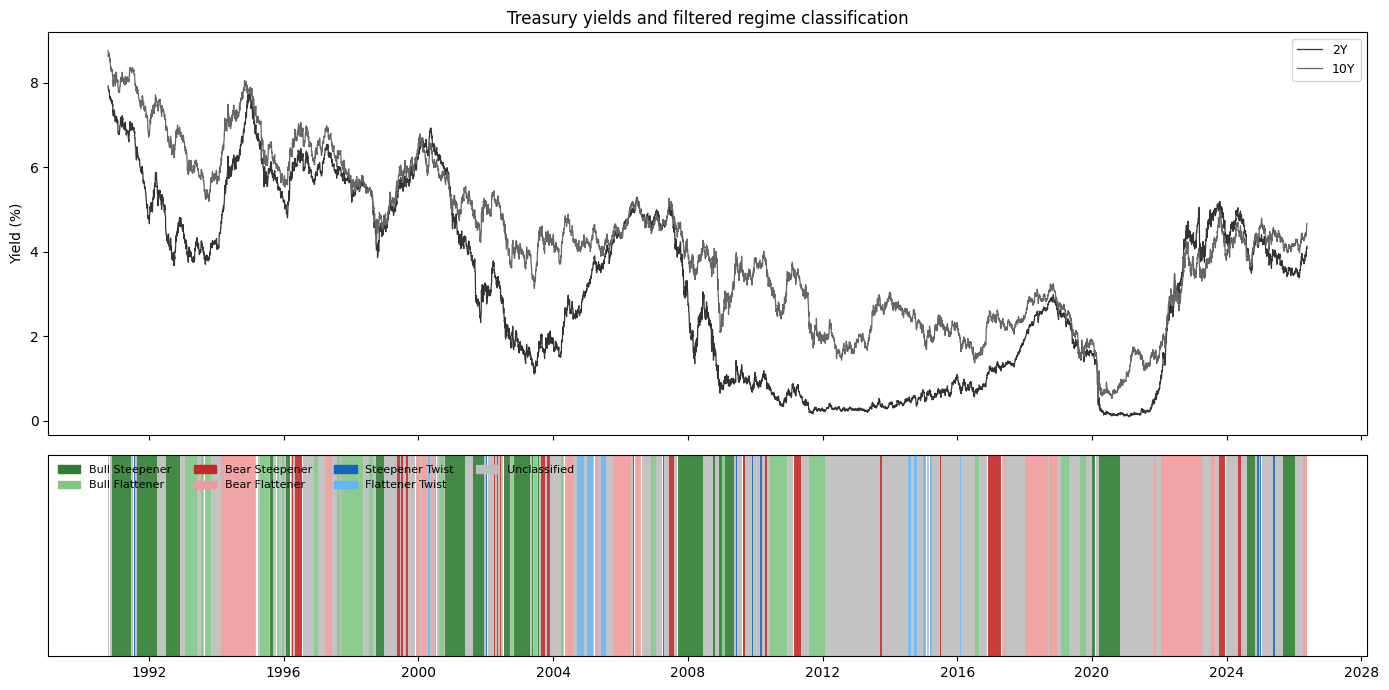

In [8]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

REGIME_ORDER = [
    "Bull Steepener",
    "Bull Flattener",
    "Bear Steepener",
    "Bear Flattener",
    "Steepener Twist",
    "Flattener Twist",
    "Unclassified",
]
REGIME_COLORS = {
    "Bull Steepener": "#2E7D32",
    "Bull Flattener": "#81C784",
    "Bear Steepener": "#C62828",
    "Bear Flattener": "#EF9A9A",
    "Steepener Twist": "#1565C0",
    "Flattener Twist": "#64B5F6",
    "Unclassified": "#BDBDBD",
}

plot_df = out.loc["1990":].copy()
runs = (plot_df["regime_filtered"] != plot_df["regime_filtered"].shift()).cumsum()

fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True, gridspec_kw={"height_ratios": [2, 1]})

ax_y = axes[0]
ax_y.plot(plot_df.index, plot_df["y2"], label="2Y", linewidth=0.9, color="#333333")
ax_y.plot(plot_df.index, plot_df["y10"], label="10Y", linewidth=0.9, color="#666666")
ax_y.set_ylabel("Yield (%)")
ax_y.legend(loc="upper right", fontsize=9)
ax_y.set_title("Treasury yields and filtered regime classification")

ax_r = axes[1]
for _, block in plot_df.groupby(runs):
    regime = block["regime_filtered"].iloc[0]
    ax_r.axvspan(
        block.index[0],
        block.index[-1],
        color=REGIME_COLORS.get(regime, "#CCCCCC"),
        alpha=0.9,
        linewidth=0,
    )
ax_r.set_yticks([])
ax_r.set_xlabel("")

handles = [
    mpatches.Patch(color=REGIME_COLORS[r], label=r)
    for r in REGIME_ORDER
    if r in plot_df["regime_filtered"].unique()
]
ax_r.legend(handles=handles, loc="upper left", ncol=4, fontsize=8, frameon=False)

plt.tight_layout()
plt.show()

In [9]:
with pd.ExcelWriter(OUT_XLSX, engine="openpyxl") as xw:
    out.reset_index().to_excel(xw, sheet_name="Regime Classification", index=False)
    pd.DataFrame({"regime": freq.index, "frequency_1990_present": freq.values}).to_excel(
        xw, sheet_name="Frequencies", index=False
    )
print("Wrote:", OUT_XLSX.resolve())

Wrote: /Users/jimmyzheng0516/Desktop/Project Labs/LTCM_sp_2026/data/interest_rate_regimes.xlsx
